# Task 3 — Data Visualization

## 1. Import Libraries

In [48]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [49]:
df = pd.read_csv("/Users/siddharthkushwaha/Desktop/CodeSoft/CodeSoft_Task3/Cleaned_online_retail.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## 3. Basic Information

In [50]:
df.shape 

(401564, 8)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401564 entries, 0 to 401563
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401564 non-null  object 
 1   StockCode    401564 non-null  object 
 2   Description  401564 non-null  object 
 3   Quantity     401564 non-null  int64  
 4   InvoiceDate  401564 non-null  object 
 5   UnitPrice    401564 non-null  float64
 6   CustomerID   401564 non-null  int64  
 7   Country      401564 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 24.5+ MB


## 4. Prepare Data

Convert date:

In [52]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

### Create Total Sales:

In [53]:
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

### Create month:

In [54]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")


## 5. Monthly Sales Trend — Line Chart

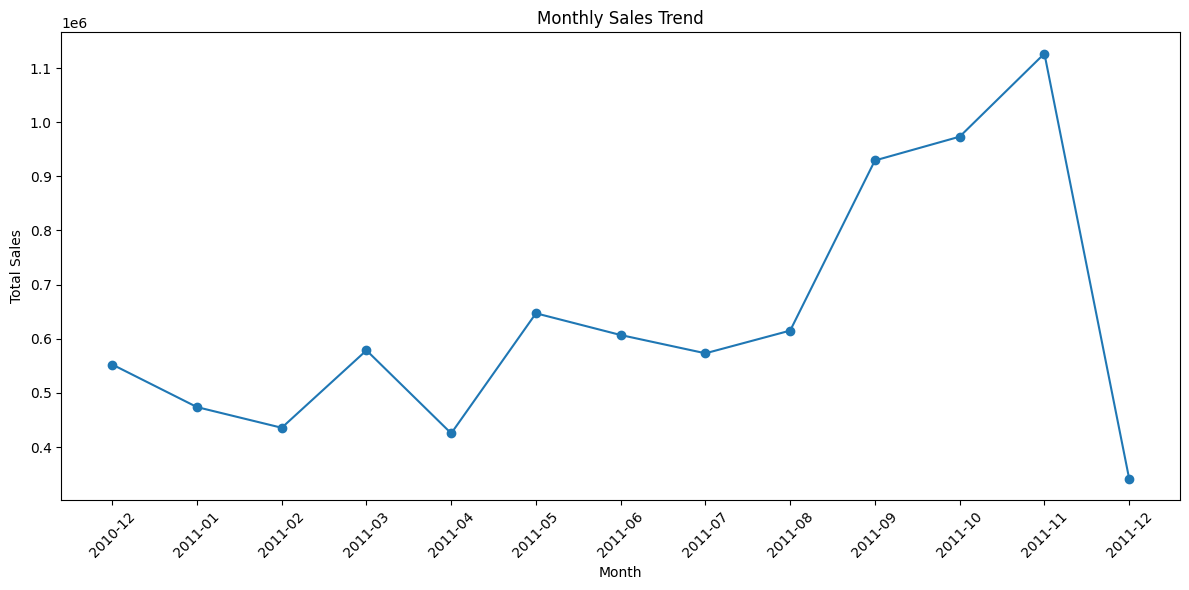

In [55]:
monthly_sales = (df.groupby("Month")["TotalSales"].sum())

plt.figure(figsize=(12, 6))

plt.plot(monthly_sales.index.astype(str),monthly_sales.values,marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6. Top 10 Countries by Revenue — Bar Chart

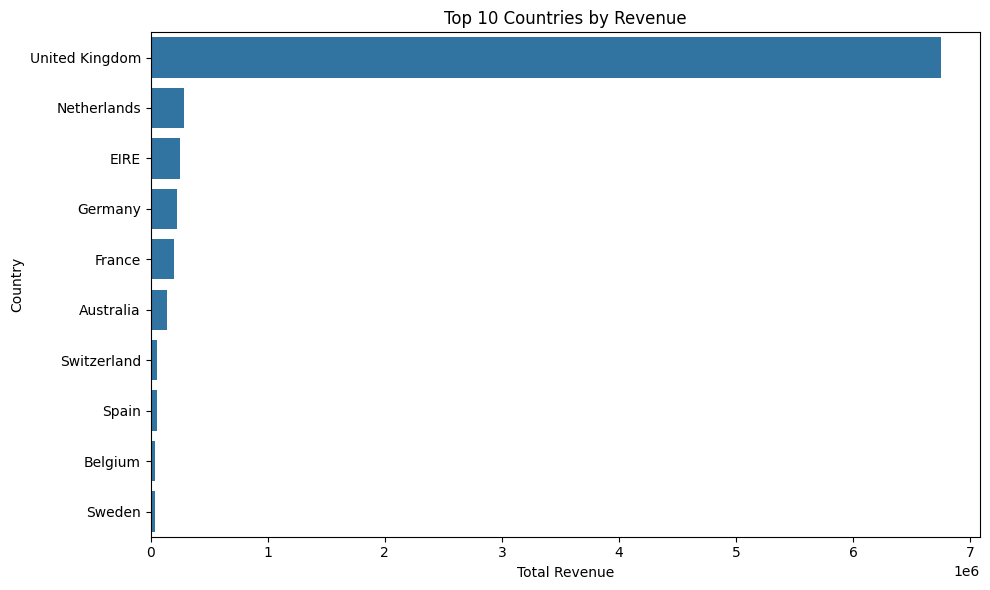

In [56]:
country_sales = (df.groupby("Country")["TotalSales"].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 6))

sns.barplot(x=country_sales.values,y=country_sales.index)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

## 7. Top 10 Products by Quantity — Bar Chart

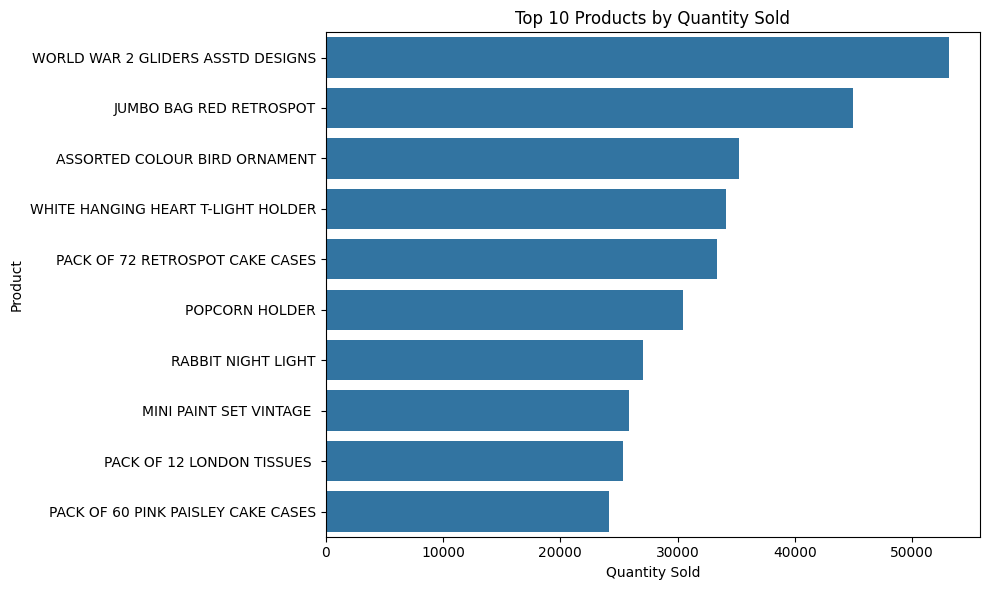

In [57]:
top_products = (df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 6))

sns.barplot(x=top_products.values,y=top_products.index)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### 8. Sales Distribution — Histogram

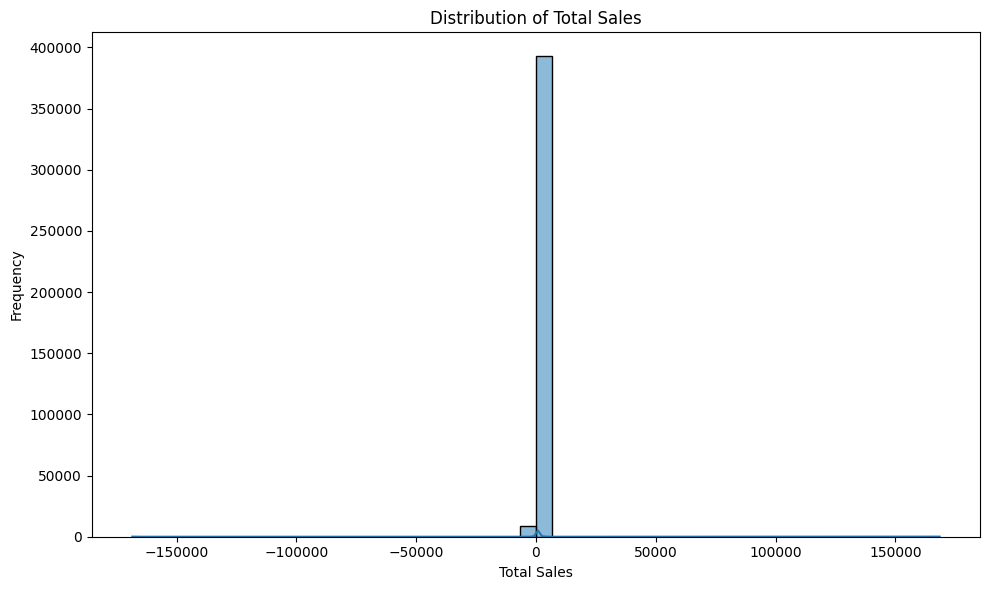

In [58]:
plt.figure(figsize=(10, 6))

sns.histplot(df["TotalSales"],bins=50,kde=True)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 9. Quantity vs Total Sales — Scatter Plota

In [59]:
sample_df = df.sample(5000, random_state=42)

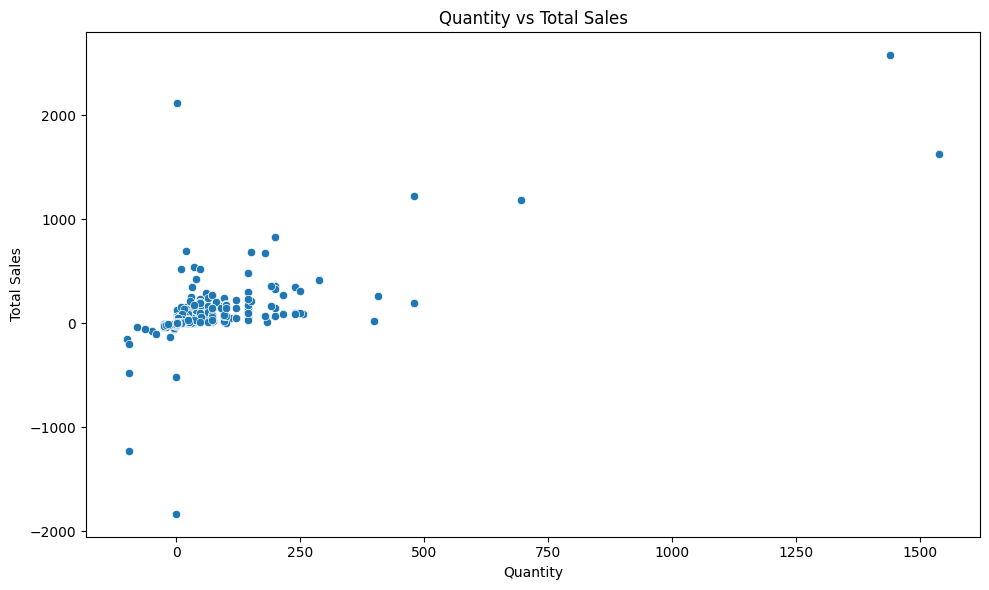

In [60]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="Quantity",
    y="TotalSales"
)

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

## 10. Revenue by Country — Pie Chart

For a pie chart, use the top 5 countries:

In [61]:
top_5_countries = (df.groupby("Country")["TotalSales"].sum()
    .sort_values(ascending=False)
    .head(5))

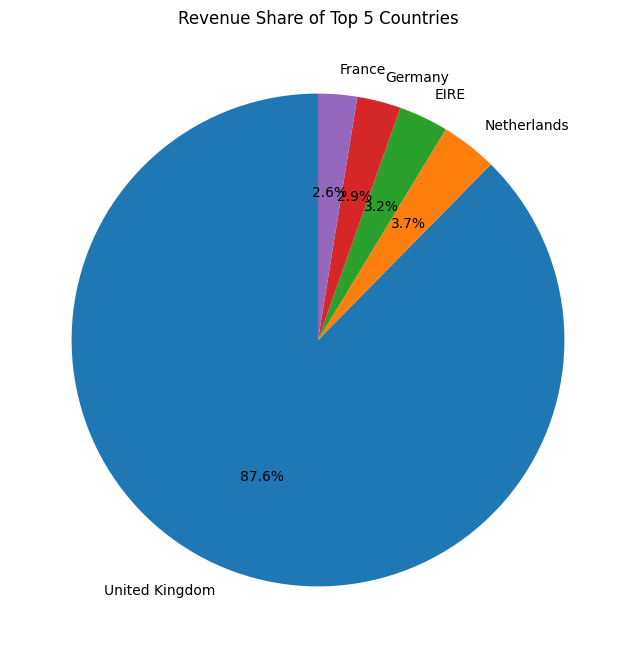

In [62]:
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_countries.values,
    labels=top_5_countries.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share of Top 5 Countries")

plt.show()

## 11. Unit Price Distribution — Box Plot

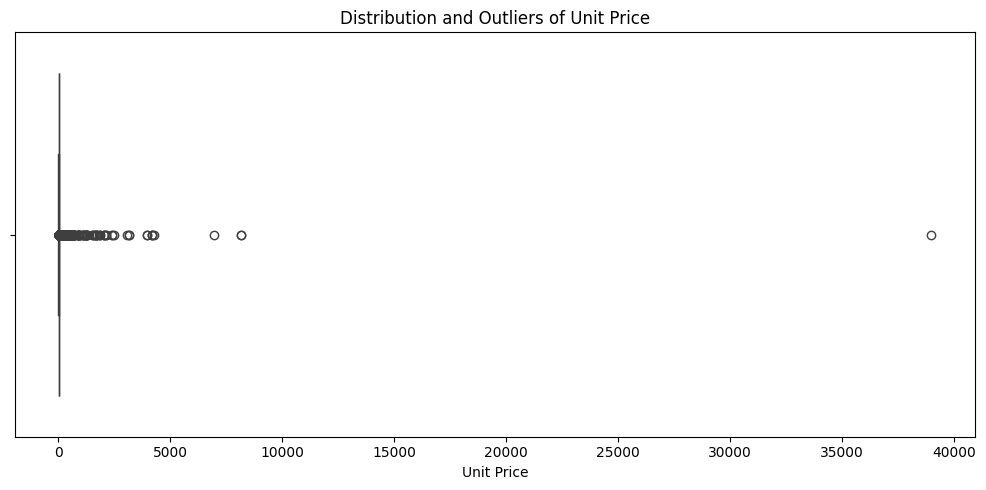

In [63]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["UnitPrice"]
)

plt.title("Distribution and Outliers of Unit Price")
plt.xlabel("Unit Price")

plt.tight_layout()
plt.show()

##  12. Quantity Distribution — Box Plot

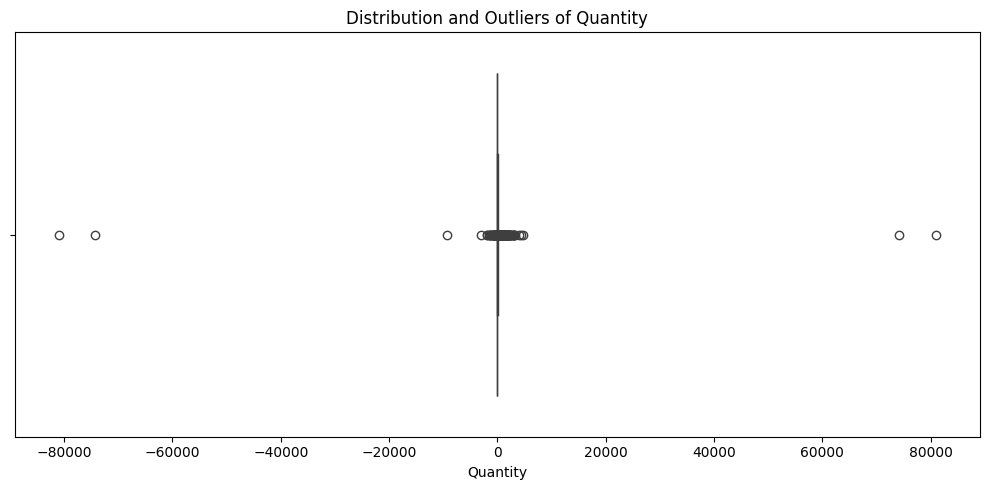

In [64]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["Quantity"])

plt.title("Distribution and Outliers of Quantity")
plt.xlabel("Quantity")

plt.tight_layout()
plt.show()

## 13. Correlation Heatmap

In [65]:
numeric_cols = [
    "Quantity",
    "UnitPrice",
    "TotalSales"]

correlation = df[numeric_cols].corr()

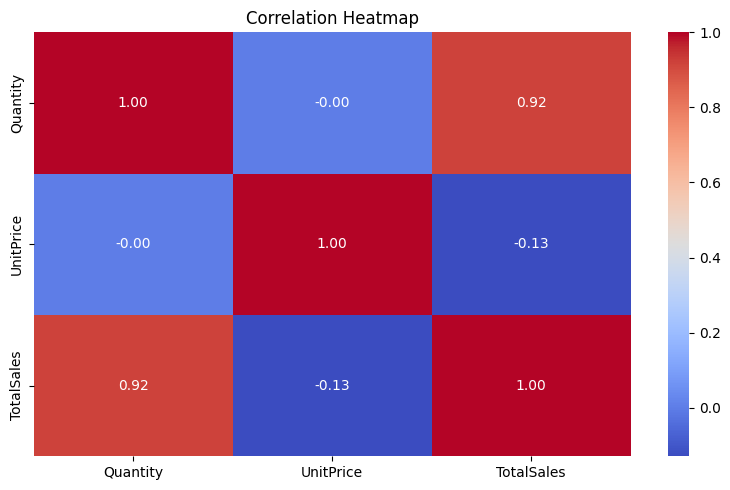

In [66]:
plt.figure(figsize=(8, 5))

sns.heatmap(correlation,annot=True,fmt=".2f",cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## 14. Top 10 Customers by Revenue

In [67]:
top_customers = (
    df.groupby("CustomerID")["TotalSales"].sum().sort_values(ascending=False)
    .head(10))

top_customers

CustomerID
14646    279489.02
18102    256438.49
17450    187322.17
14911    132458.73
12415    123725.45
14156    113214.59
17511     88125.38
16684     65892.08
13694     62690.54
15311     59284.19
Name: TotalSales, dtype: float64

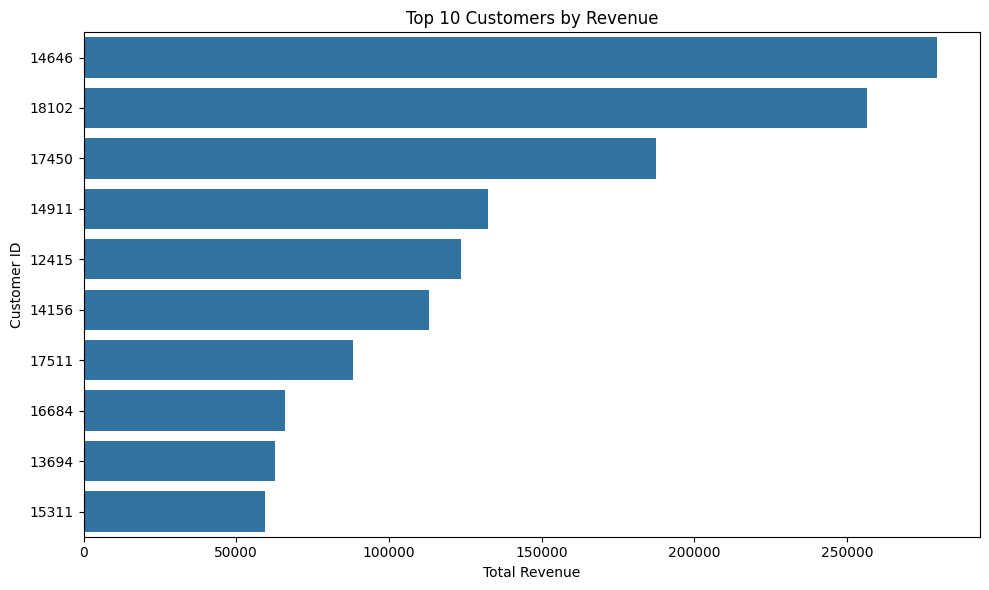

In [68]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

## 15. Create a Combined Visualization

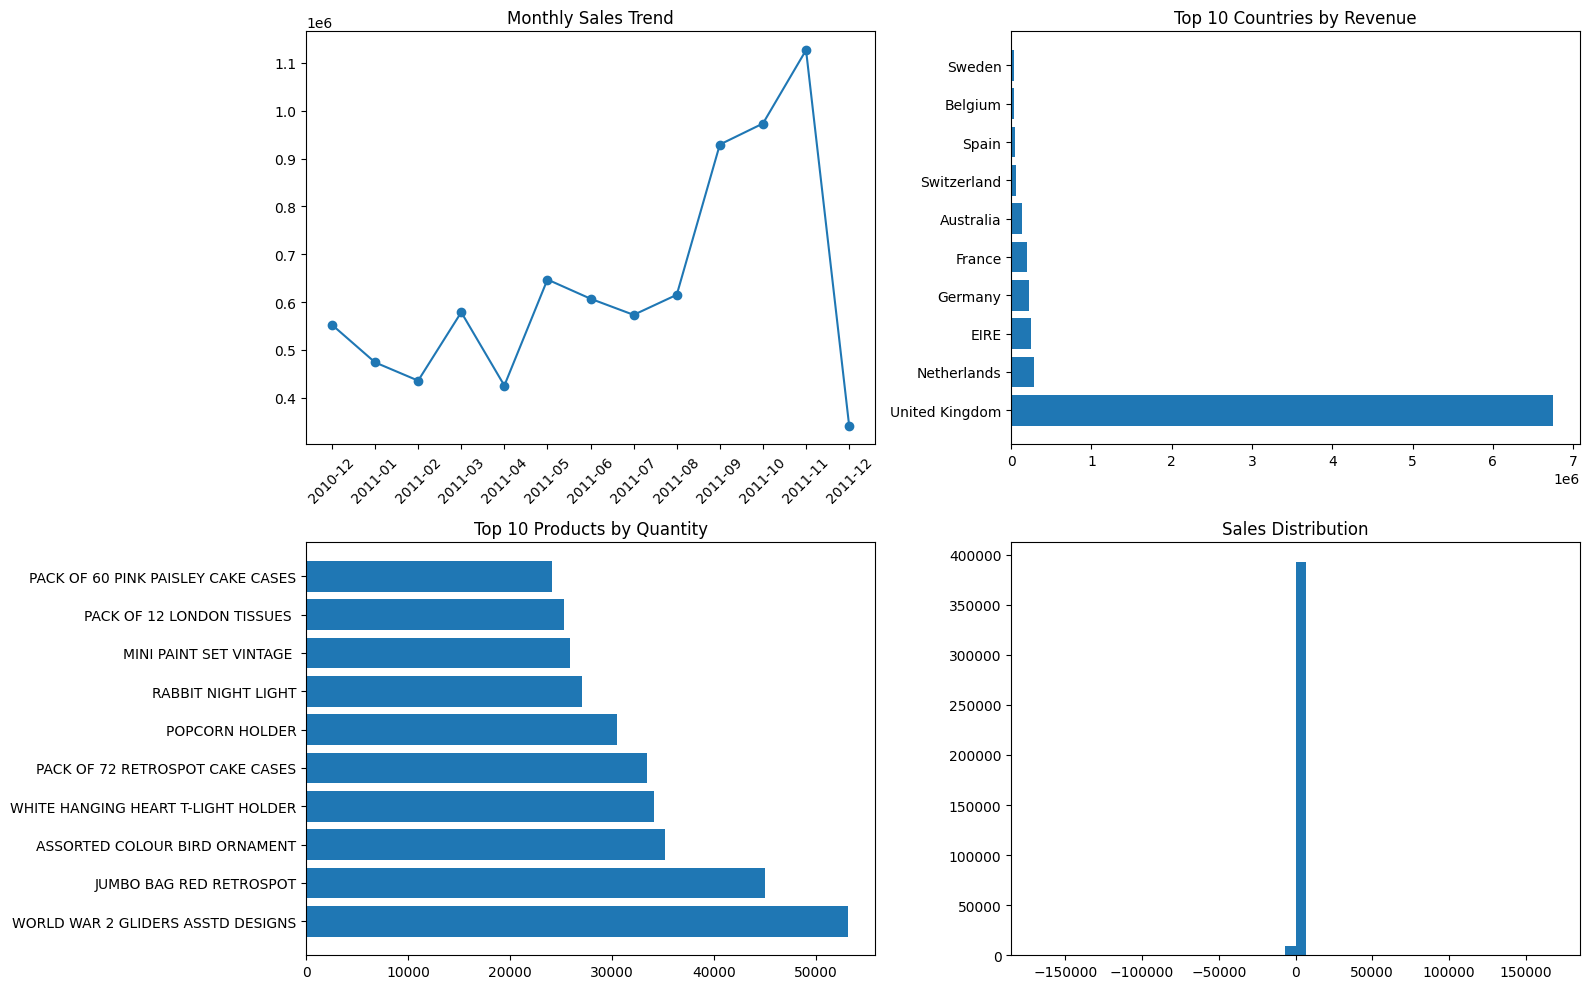

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Monthly Sales
axes[0, 0].plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)
axes[0, 0].set_title("Monthly Sales Trend")
axes[0, 0].tick_params(axis="x", rotation=45)

# Top Countries
axes[0, 1].barh(
    country_sales.index,
    country_sales.values
)
axes[0, 1].set_title("Top 10 Countries by Revenue")

# Top Products
axes[1, 0].barh(
    top_products.index,
    top_products.values
)
axes[1, 0].set_title("Top 10 Products by Quantity")

# Sales Distribution
axes[1, 1].hist(
    df["TotalSales"],
    bins=50
)
axes[1, 1].set_title("Sales Distribution")

plt.tight_layout()
plt.show()

## 16. Final Visualization Summary

## Data Visualization Summary

### Key Visual Insights

1. The monthly sales chart shows the variation in revenue over time.

2. The country-wise revenue chart identifies the major markets contributing
   to overall sales.

3. The product analysis highlights the products with the highest sales volume.

4. The histogram shows the distribution of transaction-level sales.

5. The scatter plot shows the relationship between quantity purchased
   and total sales.

6. The pie chart provides a visual representation of revenue contribution
   from the top countries.

7. Box plots highlight unusual values and potential outliers in Quantity
   and UnitPrice.

8. The correlation heatmap shows relationships between numerical variables.

### Business Insights

- High-revenue countries can be prioritized for regional business strategies.
- Popular products can be prioritized for inventory management.
- Monthly sales trends can support sales and marketing planning.
- High-value customers can be targeted for customer retention strategies.
- Outlier transactions should be investigated to determine whether they
  represent genuine bulk purchases or unusual transactions.